In [1]:
BINANCE_SYMBOL = "BTCUSDT"
BINANCE_INTERVAL = "1h"
MIN_SWING_CANDLES = 3
TREND_CONFIRMATION_PCT = 0.03

USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO = 0.15
USE_MOMENTUM_FILTER = True
MIN_MOMENTUM_RATIO = 0.5
USE_DOMINANCE_FILTER = True
MIN_DOMINANCE_RATIO = 1.5

In [2]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.adapters.binance_data import fetch_binance_ohlc_sync

candles = fetch_binance_ohlc_sync(BINANCE_SYMBOL, BINANCE_INTERVAL)
print(f"Loaded candles: {len(candles)}")
if candles:
    print(f"Range: {candles[0].timestamp} -> {candles[-1].timestamp}")

Loaded candles: 3000
Range: 2025-11-11 17:00:00+00:00 -> 2026-03-16 16:00:00+00:00


In [3]:
from src.core.trend_id import identify_trend, compute_internal_structure
from src.core.retracement_depth import annotate_legs_with_depth
from src.core.structure_levels import compute_all_structure_levels, compute_internal_structure_levels

result = identify_trend(
    candles,
    min_swing_candles=MIN_SWING_CANDLES,
    trend_confirmation_pct=TREND_CONFIRMATION_PCT,
    use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
    min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
    use_momentum_filter=USE_MOMENTUM_FILTER,
    min_momentum_ratio=MIN_MOMENTUM_RATIO,
    use_dominance_filter=USE_DOMINANCE_FILTER,
    min_dominance_ratio=MIN_DOMINANCE_RATIO,
)

compute_internal_structure(
    candles,
    result["legs"],
    min_swing_candles=MIN_SWING_CANDLES,
    use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
    min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
    use_momentum_filter=USE_MOMENTUM_FILTER,
    min_momentum_ratio=MIN_MOMENTUM_RATIO,
    use_dominance_filter=USE_DOMINANCE_FILTER,
    min_dominance_ratio=MIN_DOMINANCE_RATIO,
)

structure = compute_all_structure_levels(candles, result["legs"], result["trend"])
bos_levels = structure["bos_levels"]
choch_level = structure["choch_level"]
compute_internal_structure_levels(candles, result["legs"])
annotate_legs_with_depth(result["legs"])
for leg in result["legs"]:
    if leg.get("internal_structure"):
        annotate_legs_with_depth(leg["internal_structure"]["legs"])

result["structure_levels"] = structure
print(f"Trend: {result['trend']} | legs={len(result['legs'])} | current_phase={result['current_phase']}")
print(f"BOS levels: {len(bos_levels)} | CHoCH: {choch_level is not None}")

Trend: down | legs=5 | current_phase=impulse
BOS levels: 2 | CHoCH: True


In [4]:
def measure_feature_lags(candles, result):
    records = []
    last_index = len(candles) - 1

    def add_leg_record(feature, start_index, end_index, confirm_index, event_price):
        if start_index is None or start_index < 0 or start_index > last_index:
            return
        if end_index is None:
            end_index = last_index
        if end_index < 0 or end_index > last_index:
            return
        if confirm_index is None:
            return

        confirm_index = min(confirm_index, last_index)
        if confirm_index < start_index:
            return

        records.append({
            "feature": feature,
            "start_index": int(start_index),
            "event_index": int(end_index),
            "confirm_index": int(confirm_index),
            "lag_candles": int(confirm_index - end_index),
            "event_price": float(event_price),
            "event_timestamp": candles[end_index].timestamp,
        })

    def add_level_record(feature, event_index, confirm_index, event_price):
        if event_index is None or event_index < 0 or event_index > last_index:
            return
        if confirm_index is None:
            return

        confirm_index = min(confirm_index, last_index)
        if confirm_index < event_index:
            return

        records.append({
            "feature": feature,
            "start_index": int(event_index),
            "event_index": int(event_index),
            "confirm_index": int(confirm_index),
            "lag_candles": int(confirm_index - event_index),
            "event_price": float(event_price),
            "event_timestamp": candles[event_index].timestamp,
        })

    for leg in result["legs"]:
        start_index = leg.get("start_index")
        end_index = leg.get("end_index")
        end_for_event = end_index if end_index is not None else last_index
        event_price = (
            leg.get("end_price")
            if leg.get("end_price") is not None
            else candles[end_for_event].close
        )
        confirm_index = (
            end_index + MIN_SWING_CANDLES
            if leg.get("confirmed") is True and end_index is not None
            else last_index
        )

        if leg.get("type") == "impulse":
            add_leg_record(
                "global_impulse",
                start_index,
                end_for_event,
                confirm_index,
                event_price,
            )
        elif leg.get("type") == "retracement":
            add_leg_record(
                "global_retracement",
                start_index,
                end_for_event,
                confirm_index,
                event_price,
            )

        internal = leg.get("internal_structure")
        if (
            internal is None
            or leg.get("start_index") is None
            or leg.get("end_index") is None
        ):
            continue

        parent_start = leg["start_index"]
        parent_end = leg["end_index"]
        for internal_leg in internal.get("legs", []):
            i_start = internal_leg.get("start_index")
            i_end = internal_leg.get("end_index")

            if i_start is None:
                continue

            start_index = parent_start + i_start
            if start_index > parent_end:
                continue

            if i_end is None:
                end_index = parent_end
            else:
                end_index = min(parent_start + i_end, parent_end)

            if end_index < start_index:
                continue

            event_price = (
                internal_leg.get("end_price")
                if internal_leg.get("end_price") is not None
                else candles[end_index].close
            )
            confirm_index = (
                end_index + MIN_SWING_CANDLES
                if internal_leg.get("confirmed") is True and i_end is not None
                else last_index
            )

            if internal_leg.get("type") == "impulse":
                add_leg_record(
                    "internal_impulse",
                    start_index,
                    end_index,
                    confirm_index,
                    event_price,
                )
            elif internal_leg.get("type") == "retracement":
                add_leg_record(
                    "internal_retracement",
                    start_index,
                    end_index,
                    confirm_index,
                    event_price,
                )

    levels = result.get("structure_levels")
    if levels is None:
        levels = compute_all_structure_levels(candles, result["legs"], result["trend"])

    for bos in levels.get("bos_levels", []):
        event_index = bos.get("start_index")
        if event_index is None:
            continue
        add_level_record(
            "bos",
            event_index,
            event_index + 1,
            candles[event_index].close,
        )

    choch = levels.get("choch_level")
    if choch is not None and choch.get("start_index") is not None:
        event_index = choch["start_index"]
        add_level_record(
            "choch",
            event_index,
            event_index + 1,
            candles[event_index].close,
        )

    return sorted(records, key=lambda row: (row["start_index"], row["event_index"]))

In [5]:
import pandas as pd

result["structure_levels"] = structure
lag_rows = measure_feature_lags(candles, result)

if not lag_rows:
    print("No lag records found.")
else:
    lag_df = pd.DataFrame(lag_rows)
    summary_df = (
        lag_df.groupby("feature", as_index=False)
        .agg(count=("lag_candles", "size"), mean_lag=("lag_candles", "mean"), min_lag=("lag_candles", "min"), max_lag=("lag_candles", "max"))
    )
    summary_df["mean_lag"] = summary_df["mean_lag"].round(1)
    summary_df = summary_df.sort_values("feature").reset_index(drop=True)

    print("Feature               count  mean_lag  min_lag  max_lag")
    for _, row in summary_df.iterrows():
        print(f"{row['feature']:<20}{int(row['count']):>6}{row['mean_lag']:>10.1f}{int(row['min_lag']):>9}{int(row['max_lag']):>9}")

Feature               count  mean_lag  min_lag  max_lag
bos                      2       1.0        1        1
choch                    1       1.0        1        1
global_impulse           3       2.0        0        3
global_retracement       2       3.0        3        3
internal_impulse         4       3.0        3        3
internal_retracement     4     924.5        3     2764


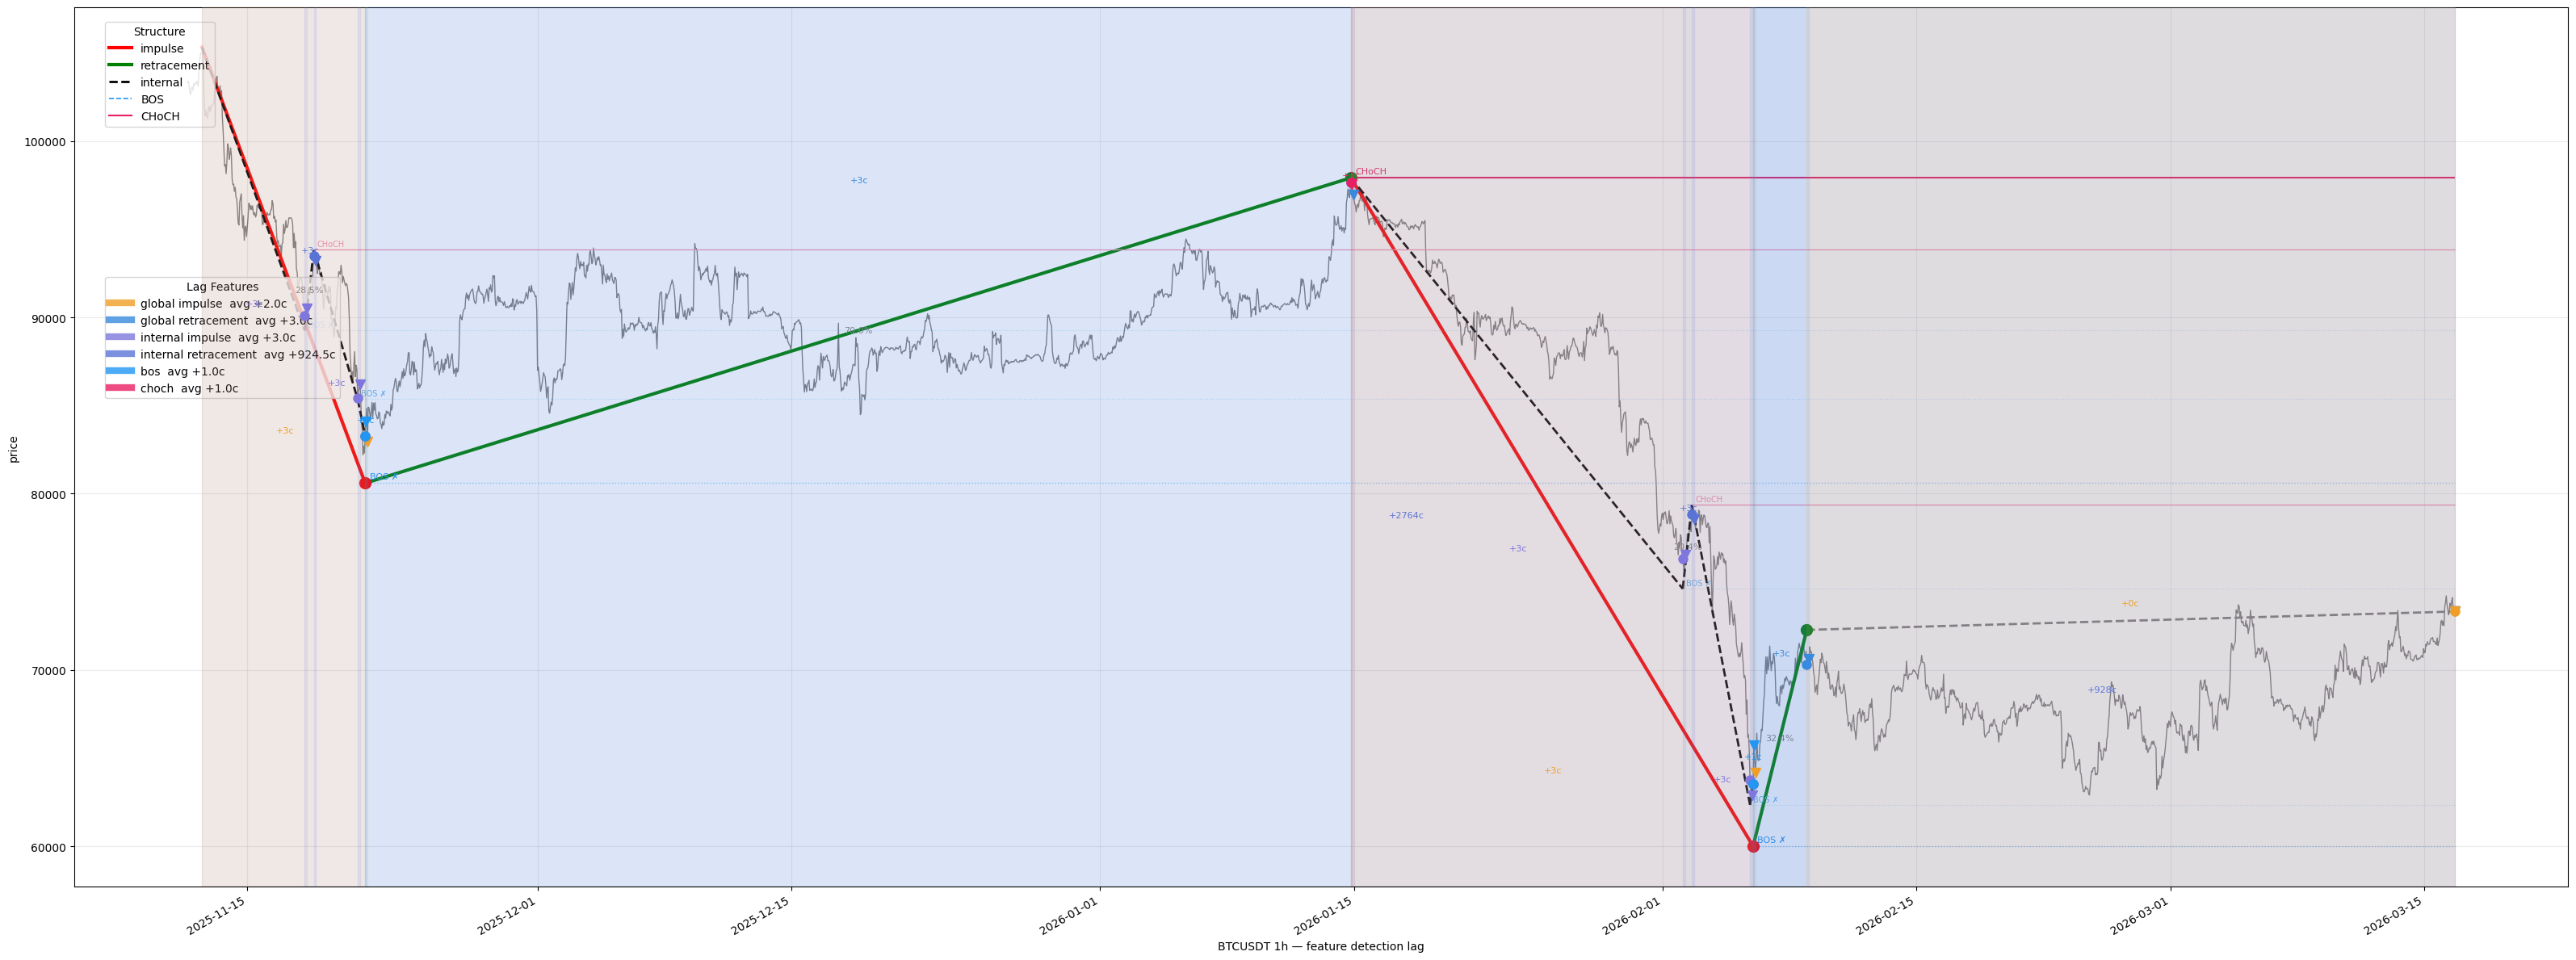

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

feature_colors = {
    "global_impulse": "#EF9F27",
    "global_retracement": "#378ADD",
    "internal_impulse": "#7F77DD",
    "internal_retracement": "#5A74D6",
    "bos": "#2196F3",
    "choch": "#E91E63",
}

display = candles
lag_rows = measure_feature_lags(candles, result)

fig, ax = plt.subplots(figsize=(32, 12))

x_values = [c.timestamp for c in display]
prices = [c.close for c in display]
ax.plot(x_values, prices, color='black', alpha=0.5, linewidth=1)

def x_at(index):
    return display[index].timestamp

chart_end_x = x_at(len(candles) - 1)

# Draw outer legs
for leg in result["legs"]:
    start_idx = leg["start_index"]
    end_idx = leg["end_index"] if leg["end_index"] is not None else len(display) - 1

    start_x = x_at(start_idx)
    end_x = x_at(end_idx)

    start_y = leg["start_price"]
    end_y = leg["end_price"] if leg["end_price"] is not None else display[-1].close

    if result["trend"] == "down":
        color = "red" if leg["type"] == "impulse" else "green"
    else:
        color = "green" if leg["type"] == "impulse" else "red"

    if not leg["confirmed"]:
        ax.plot([start_x, end_x], [start_y, end_y], color='grey', linestyle='--', linewidth=2)
    else:
        ax.plot([start_x, end_x], [start_y, end_y], color=color, linewidth=3)
        ax.scatter(end_x, end_y, color=color, s=100, zorder=5)

# Draw internal structure only within the parent impulse span.
for leg in result["legs"]:
    internal = leg.get("internal_structure")
    parent_start = leg["start_index"]
    parent_end = leg["end_index"]

    if internal is None or parent_end is None:
        continue

    for internal_leg in internal["legs"]:
        relative_start = internal_leg["start_index"]
        relative_end = internal_leg["end_index"] if internal_leg["end_index"] is not None else parent_end - parent_start

        start_idx = parent_start + relative_start
        end_idx = parent_start + relative_end
        end_idx = min(end_idx, parent_end)

        start_x = x_at(start_idx)
        end_x = x_at(end_idx)

        start_y = internal_leg["start_price"]
        if internal_leg["end_price"] is not None:
            end_y = internal_leg["end_price"]
        else:
            end_y = display[end_idx].close

        ax.plot([start_x, end_x], [start_y, end_y], color='black', linestyle='--', linewidth=2)

def annotate_retracement_depth_label(leg, index_offset=0, max_end_index=None):
    depth = leg.get("retracement_depth")
    if depth is None:
        return
    if leg.get("type") != "retracement" or leg.get("confirmed") is not True:
        return
    if leg.get("start_index") is None or leg.get("end_index") is None:
        return

    start_index = leg["start_index"] + index_offset
    end_index = leg["end_index"] + index_offset
    if max_end_index is not None:
        end_index = min(end_index, max_end_index)

    mid_index = (start_index + end_index) // 2
    start_price = float(leg["start_price"])
    end_price = float(leg["end_price"])
    mid_price = (start_price + end_price) / 2.0
    ax.text(
        x_at(mid_index),
        mid_price,
        f"{depth['depth_pct']}%",
        fontsize=8,
        color="#888780",
        ha="center",
        va="center",
        zorder=8,
    )

for leg in result["legs"]:
    annotate_retracement_depth_label(leg)

for parent_leg in result["legs"]:
    internal = parent_leg.get("internal_structure")
    if (
        internal is None
        or parent_leg.get("start_index") is None
        or parent_leg.get("end_index") is None
    ):
        continue

    parent_start = parent_leg["start_index"]
    parent_end = parent_leg["end_index"]
    for internal_leg in internal["legs"]:
        annotate_retracement_depth_label(
            internal_leg,
            index_offset=parent_start,
            max_end_index=parent_end,
        )

for bos in bos_levels:
    bos_start_x = x_at(bos["start_index"])
    if bos_start_x == chart_end_x:
        continue
    bos_label = "BOS ✗" if bos["broken"] else "BOS"
    bos_linewidth = 1.0 if bos["broken"] else 1.5
    bos_linestyle = ":" if bos["broken"] else "--"
    bos_alpha = 0.5 if bos["broken"] else 1.0
    ax.hlines(
        y=bos["price"],
        xmin=bos_start_x,
        xmax=chart_end_x,
        colors="#2196F3",
        linewidth=bos_linewidth,
        linestyles=bos_linestyle,
        alpha=bos_alpha,
        zorder=3,
    )
    ax.annotate(
        bos_label,
        xy=(bos_start_x, bos["price"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        color="#2196F3",
    )

if choch_level is not None:
    choch_start_x = x_at(choch_level["start_index"])
    choch_label = "CHoCH ✗" if choch_level["broken"] else "CHoCH"
    choch_linewidth = 1.0 if choch_level["broken"] else 1.5
    choch_linestyle = ":" if choch_level["broken"] else "-"
    choch_alpha = 0.5 if choch_level["broken"] else 1.0
    ax.hlines(
        y=choch_level["price"],
        xmin=choch_start_x,
        xmax=chart_end_x,
        colors="#E91E63",
        linewidth=choch_linewidth,
        linestyles=choch_linestyle,
        alpha=choch_alpha,
        zorder=4,
    )
    ax.annotate(
        choch_label,
        xy=(choch_start_x, choch_level["price"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        color="#E91E63",
    )

for leg in result["legs"]:
    internal_bos_levels = leg.get("internal_bos_levels") or []
    for bos in internal_bos_levels:
        bos_start_x = x_at(bos["start_index"])
        bos_label = "BOS ✗" if bos["broken"] else "BOS"
        bos_linewidth = 0.8 if bos["broken"] else 0.9
        bos_linestyle = ":" if bos["broken"] else "--"
        bos_alpha = 0.4 if bos["broken"] else 1.0
        ax.hlines(
            y=bos["price"],
            xmin=bos_start_x,
            xmax=chart_end_x,
            colors="#64B5F6",
            linewidth=bos_linewidth,
            linestyles=bos_linestyle,
            alpha=bos_alpha,
            zorder=2,
        )
        ax.annotate(
            bos_label,
            xy=(bos_start_x, bos["price"]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="#64B5F6",
        )

    internal_choch = leg.get("internal_choch_level")
    if internal_choch is not None:
        choch_start_x = x_at(internal_choch["start_index"])
        choch_label = "CHoCH ✗" if internal_choch["broken"] else "CHoCH"
        choch_linewidth = 0.8 if internal_choch["broken"] else 0.9
        choch_linestyle = ":" if internal_choch["broken"] else "-"
        choch_alpha = 0.4 if internal_choch["broken"] else 1.0
        ax.hlines(
            y=internal_choch["price"],
            xmin=choch_start_x,
            xmax=chart_end_x,
            colors="#F48FB1",
            linewidth=choch_linewidth,
            linestyles=choch_linestyle,
            alpha=choch_alpha,
            zorder=2,
        )
        ax.annotate(
            choch_label,
            xy=(choch_start_x, internal_choch["price"]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="#F48FB1",
        )

for row in lag_rows:
    color = feature_colors.get(row["feature"], "#555555")
    start_time = candles[row["start_index"]].timestamp
    confirm_time = candles[row["confirm_index"]].timestamp
    ax.axvspan(start_time, confirm_time, color=color, alpha=0.10, zorder=9)

y_offset = (max(prices) - min(prices)) * 0.008 if prices else 0.0
for row in lag_rows:
    feature = row["feature"]
    color = feature_colors.get(feature, "#555555")

    start_time = candles[row["start_index"]].timestamp
    event_idx = row["event_index"]
    confirm_idx = row["confirm_index"]

    event_time = candles[event_idx].timestamp
    confirm_time = candles[confirm_idx].timestamp

    event_close = candles[event_idx].close
    confirm_close = candles[confirm_idx].close

    ax.plot(
        event_time,
        event_close,
        marker="o",
        color=color,
        markersize=8,
        linestyle="None",
        zorder=10,
    )
    ax.plot(
        confirm_time,
        confirm_close,
        marker="v",
        color=color,
        markersize=8,
        linestyle="None",
        zorder=10,
    )

    midpoint_num = (mdates.date2num(start_time) + mdates.date2num(confirm_time)) / 2
    midpoint_time = mdates.num2date(midpoint_num).replace(tzinfo=None)
    midpoint_price = (event_close + confirm_close) / 2 + y_offset
    ax.text(
        midpoint_time,
        midpoint_price,
        f"+{row['lag_candles']}c",
        fontsize=8,
        color=color,
        ha="center",
        zorder=11,
    )

structure_handles = [
    Line2D([0], [0], color="red", lw=3, label="impulse"),
    Line2D([0], [0], color="green", lw=3, label="retracement"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="internal"),
    Line2D([0], [0], color="#2196F3", lw=1.2, linestyle="--", label="BOS"),
    Line2D([0], [0], color="#E91E63", lw=1.5, linestyle="-", label="CHoCH"),
]
structure_legend = ax.legend(
    handles=structure_handles,
    title="Structure",
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
)
ax.add_artist(structure_legend)

lag_handles = []
lag_df_overlay = pd.DataFrame(lag_rows) if lag_rows else pd.DataFrame(columns=["feature", "lag_candles"])
avg_lag = lag_df_overlay.groupby("feature")["lag_candles"].mean().to_dict()
legend_order = [
    "global_impulse",
    "global_retracement",
    "internal_impulse",
    "internal_retracement",
    "bos",
    "choch",
]
legend_labels = {
    "global_impulse": "global impulse",
    "global_retracement": "global retracement",
    "internal_impulse": "internal impulse",
    "internal_retracement": "internal retracement",
    "bos": "bos",
    "choch": "choch",
}

for feature in legend_order:
    if feature not in avg_lag:
        continue
    lag_handles.append(
        Line2D(
            [0],
            [0],
            color=feature_colors[feature],
            lw=6,
            alpha=0.8,
            label=f"{legend_labels[feature]}  avg +{avg_lag[feature]:.1f}c",
        )
    )

if lag_handles:
    ax.legend(
        handles=lag_handles,
        title="Lag Features",
        loc="upper left",
        bbox_to_anchor=(0.01, 0.70),
        frameon=True,
)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_xlabel(f"{BINANCE_SYMBOL} {BINANCE_INTERVAL} — feature detection lag")
ax.set_ylabel("price")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

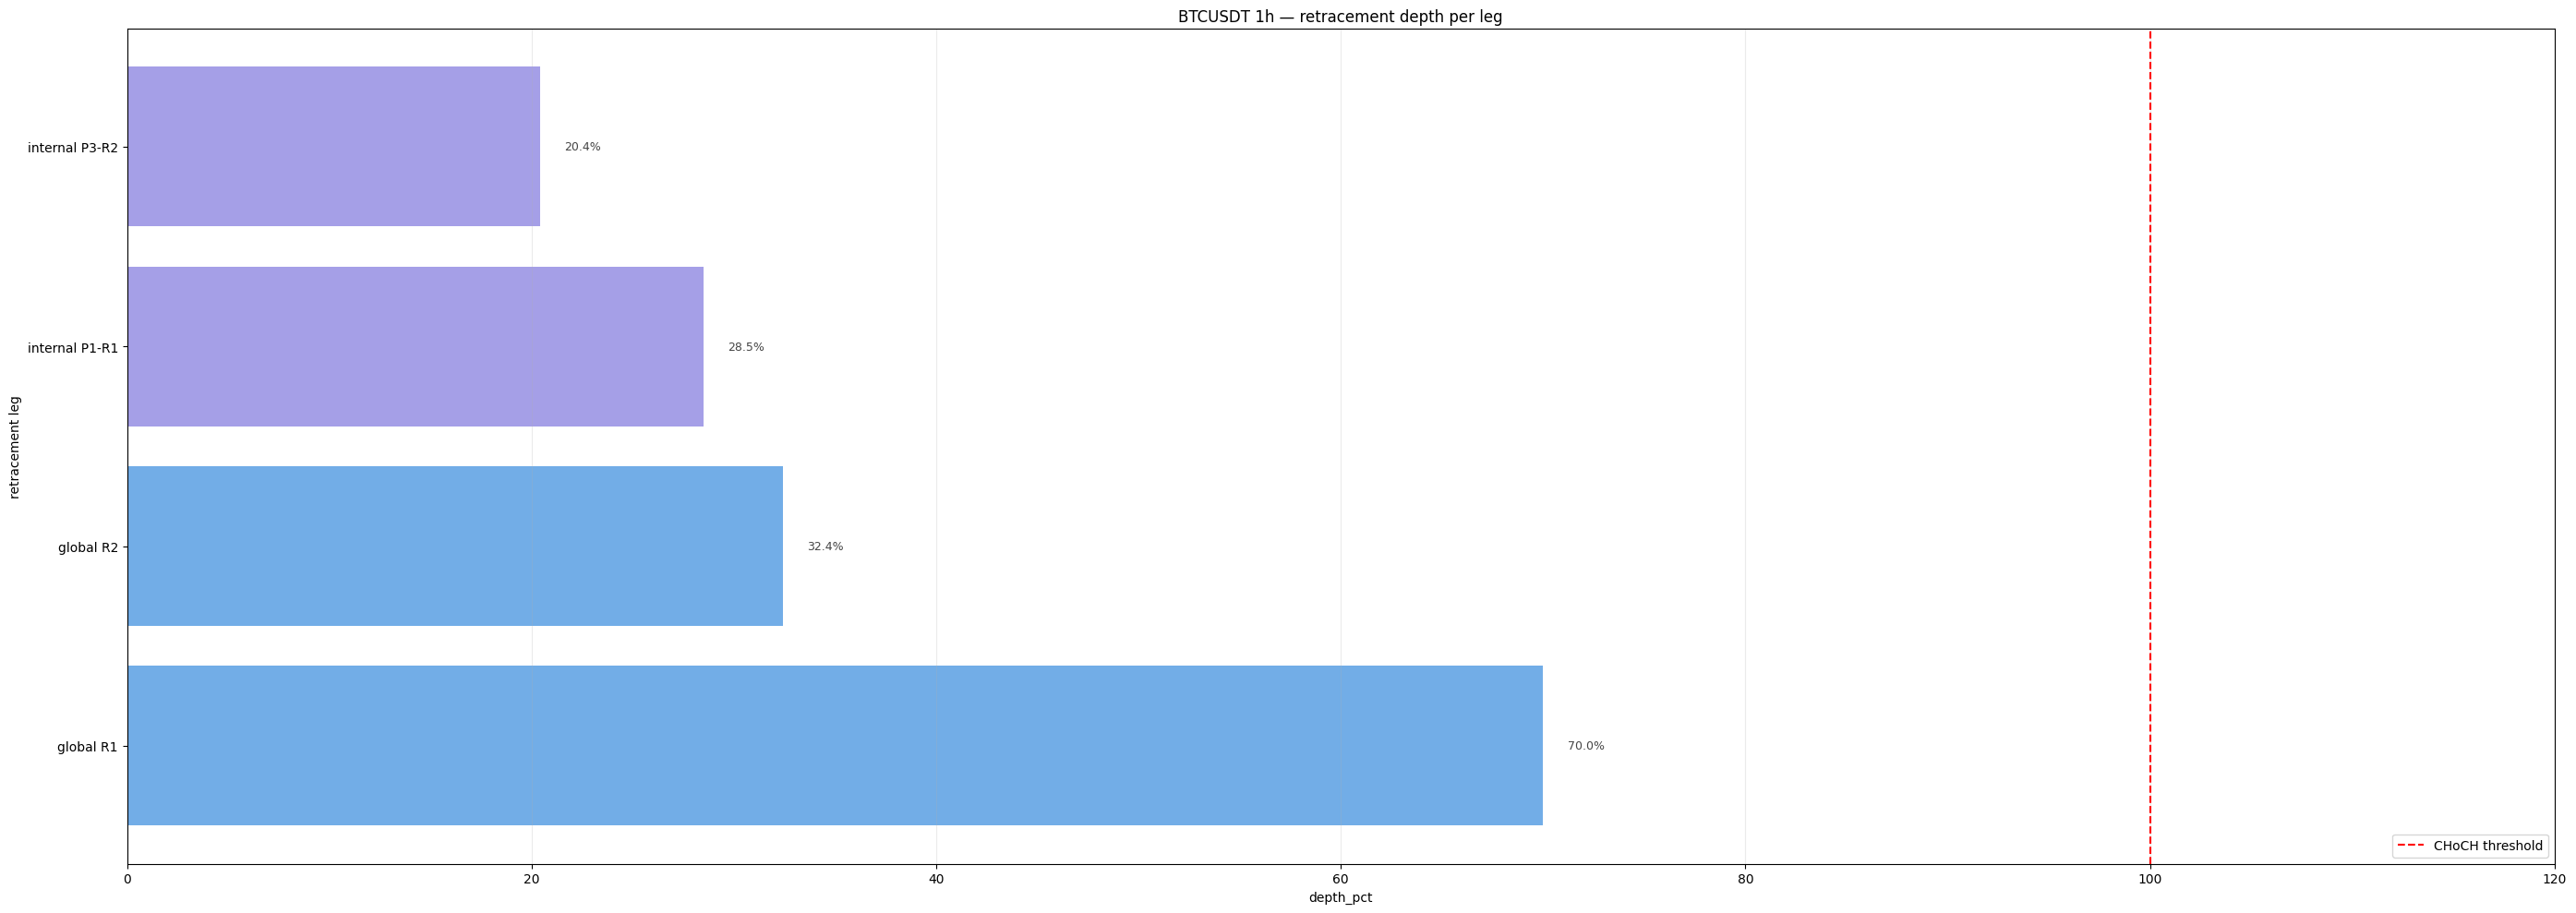

In [7]:
depth_rows = []

global_idx = 0
internal_idx = 0
for leg in result["legs"]:
    depth = leg.get("retracement_depth")
    if leg.get("type") == "retracement" and isinstance(depth, dict) and depth.get("confirmed") is True:
        global_idx += 1
        depth_rows.append({
            "label": f"global R{global_idx}",
            "depth_pct": float(depth["depth_pct"]),
            "scope": "global",
        })

for parent_i, leg in enumerate(result["legs"], start=1):
    internal = leg.get("internal_structure")
    if not internal:
        continue
    for internal_leg in internal.get("legs", []):
        depth = internal_leg.get("retracement_depth")
        if internal_leg.get("type") == "retracement" and isinstance(depth, dict) and depth.get("confirmed") is True:
            internal_idx += 1
            depth_rows.append({
                "label": f"internal P{parent_i}-R{internal_idx}",
                "depth_pct": float(depth["depth_pct"]),
                "scope": "internal",
            })

if not depth_rows:
    print("No confirmed retracement depths to plot.")
else:
    depth_df = pd.DataFrame(depth_rows)
    colors = depth_df["scope"].map({"global": "#378ADD", "internal": "#7F77DD"}).tolist()

    fig, ax = plt.subplots(figsize=(28, 10))
    bars = ax.barh(depth_df["label"], depth_df["depth_pct"], color=colors, alpha=0.7)
    ax.axvline(100.0, color="red", linewidth=1.5, linestyle="--", label="CHoCH threshold")

    for bar, value in zip(bars, depth_df["depth_pct"]):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(x + 1.2, y, f"{value:.1f}%", va="center", fontsize=9, color="#444444")

    ax.set_xlim(0, 120)
    ax.set_xlabel("depth_pct")
    ax.set_ylabel("retracement leg")
    ax.set_title(f"{BINANCE_SYMBOL} {BINANCE_INTERVAL} — retracement depth per leg")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()